<a href="https://colab.research.google.com/github/anacdutrar/Trabalho_final_grupo7-Embarcados/blob/main/notebook/WISDM_Watch_HAR_FINAL_GalaxyWatch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconhecimento de atividades no smartwatch — WISDM + LiteRT

Este notebook implementa o ciclo completo e reproduzível do trabalho: baixa o WISDM oficial, usa somente acelerômetro e giroscópio do **smartwatch**, filtra as atividades A/B/C/G/R, separa participantes antes de qualquer transformação, cria janelas temporais, treina uma CNN 1D compacta, converte para TFLite `int8` e exporta o pacote para o aplicativo Wear OS.

Além do modelo principal com fusão de acelerômetro + giroscópio, o notebook inclui ao final um experimento controlado com apenas acelerômetro, mantendo os mesmos participantes e janelas para medir o ganho real da fusão antes da escolha do modelo a ser embarcado no Wear OS.

A versão final também inclui comparação TFLite FP32 × INT8, benchmark de inferência em CPU do Colab e matriz de confusão normalizada com métricas por classe, para documentar compactação e comportamento do modelo.


In [ ]:
# Bibliotecas usadas no projeto
# Dependências do Google Colab
!pip -q install tensorflow pandas numpy scikit-learn matplotlib seaborn requests


In [ ]:
# Configurações gerais do experimento
# Janela de 5 s a 20 Hz = 100 amostras por janela
# Modelo principal usa 6 canais: Acc X/Y/Z + Gyro X/Y/Z
from pathlib import Path
from collections import Counter
import hashlib
import json
import random
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

DATA_URL = ('https://archive.ics.uci.edu/static/public/507/'
            'wisdm%2Bsmartphone%2Band%2Bsmartwatch%2Bactivity%2Band%2Bbiometrics%2Bdataset.zip')
WORK_DIR = Path('/content/watch_har')
ZIP_PATH = WORK_DIR / 'wisdm.zip'
DATA_DIR = WORK_DIR / 'dataset'
EXPORT_DIR = WORK_DIR / 'export'

ACTIVITY_CODES = ['A', 'B', 'C', 'G', 'R']
ACTIVITY_NAMES = {
    'A': 'Walking',
    'B': 'Jogging',
    'C': 'Stairs',
    'G': 'Brushing Teeth',
    'R': 'Clapping',
}
LABEL_TO_INDEX = {code: i for i, code in enumerate(ACTIVITY_CODES)}
CHANNELS = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
SAMPLE_RATE_HZ = 20
SAMPLE_PERIOD_S = 1.0 / SAMPLE_RATE_HZ
WINDOW_SECONDS = 5
WINDOW_SAMPLES = SAMPLE_RATE_HZ * WINDOW_SECONDS
HOP_SECONDS = 1
HOP_SAMPLES = SAMPLE_RATE_HZ * HOP_SECONDS
MAX_GAP_S = 0.250

print('TensorFlow:', tf.__version__)
print('Contrato:', (1, WINDOW_SAMPLES, len(CHANNELS)), ACTIVITY_CODES)


TensorFlow: 2.21.0
Contrato: (1, 100, 6) ['A', 'B', 'C', 'G', 'R']


## 1. Download e localização dos arquivos

O ZIP tem aproximadamente 295 MB. A busca pelos arquivos é feita pela estrutura e pelo nome, sem depender de uma pasta absoluta específica dentro do arquivo.

In [ ]:
# Baixa e extrai o WISDM e localiza os arquivos do smartwatch
WORK_DIR.mkdir(parents=True, exist_ok=True)
if not ZIP_PATH.exists():
    with requests.get(DATA_URL, stream=True, timeout=180) as response:
        response.raise_for_status()
        with ZIP_PATH.open('wb') as output:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    output.write(chunk)

DATA_DIR.mkdir(parents=True, exist_ok=True)
outer_marker = DATA_DIR / '.outer_zip_extracted'
if not outer_marker.exists():
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)
    outer_marker.touch()

# O pacote da UCI contém wisdm-dataset.zip dentro do ZIP externo.
# O laço também suporta novas camadas internas, caso a estrutura mude.
def extract_nested_zips(root):
    processed = set()
    while True:
        pending = [path for path in root.rglob('*.zip') if path not in processed]
        if not pending:
            break
        for nested_zip in pending:
            processed.add(nested_zip)
            destination = nested_zip.parent / f'{nested_zip.stem}_extracted'
            marker = destination / '.extraction_complete'
            if marker.exists():
                continue
            destination.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(nested_zip) as archive:
                archive.extractall(destination)
            marker.touch()
            print('ZIP interno extraído:', nested_zip.name, '->', destination)

extract_nested_zips(DATA_DIR)

def find_watch_files(sensor_name):
    matches = []
    for path in DATA_DIR.rglob('*'):
        if not path.is_file() or path.suffix.lower() != '.txt':
            continue
        name = path.name.lower()
        parts = {part.lower() for part in path.parts}
        is_watch = 'watch' in parts or '_watch' in path.stem.lower()
        is_sensor = sensor_name in parts or f'_{sensor_name}_' in name
        if name.startswith('data_') and is_watch and is_sensor:
            matches.append(path)
    return sorted(matches)

accel_files = find_watch_files('accel')
gyro_files = find_watch_files('gyro')
print('Arquivos watch/accel:', len(accel_files))
print('Arquivos watch/gyro :', len(gyro_files))
if not accel_files or not gyro_files:
    print('Arquivos encontrados após a extração (primeiros 30):')
    for candidate in list(DATA_DIR.rglob('*'))[:30]:
        print(' -', candidate.relative_to(DATA_DIR))
assert len(accel_files) == 51, 'Esperados 51 arquivos de acelerômetro do relógio'
assert len(gyro_files) == 51, 'Esperados 51 arquivos de giroscópio do relógio'


ZIP interno extraído: wisdm-dataset.zip -> /content/watch_har/dataset/wisdm-dataset_extracted
Arquivos watch/accel: 51
Arquivos watch/gyro : 51


## 2. Leitura e auditoria dos dados brutos

As unidades documentadas pelo WISDM são m/s² para acelerômetro e rad/s para giroscópio — as mesmas retornadas pelas APIs Android. O ponto e vírgula no fim de cada linha é removido explicitamente.

In [ ]:
# Leitura dos sinais e limpeza básica dos dados
# Aqui também removemos duplicatas e verificamos valores inválidos
RAW_COLUMNS = ['subject', 'activity', 'timestamp', 'x', 'y', 'z']

def read_sensor_files(paths, sensor_name):
    frames = []
    for path in paths:
        frame = pd.read_csv(
            path, header=None, names=RAW_COLUMNS, dtype=str,
            on_bad_lines='skip', engine='python',
        )
        frame['z'] = frame['z'].str.replace(';', '', regex=False)
        frame = frame[frame['activity'].isin(ACTIVITY_CODES)].copy()
        for column in ['subject', 'timestamp', 'x', 'y', 'z']:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')
        frame['sensor'] = sensor_name
        frames.append(frame)
    result = pd.concat(frames, ignore_index=True)
    result['subject'] = result['subject'].astype('Int64')
    return result

accel_raw = read_sensor_files(accel_files, 'accel')
gyro_raw = read_sensor_files(gyro_files, 'gyro')
raw = pd.concat([accel_raw, gyro_raw], ignore_index=True)

quality_before = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'null_count': raw.isna().sum(),
    'unique_values': raw.nunique(dropna=True),
})
display(quality_before)

invalid_rows = raw[['subject', 'timestamp', 'x', 'y', 'z']].isna().any(axis=1)
print('Linhas inválidas removidas:', int(invalid_rows.sum()))
raw = raw.loc[~invalid_rows].copy()
raw['subject'] = raw['subject'].astype(int)

duplicate_key = ['sensor', 'subject', 'activity', 'timestamp']
duplicate_count = int(raw.duplicated(duplicate_key).sum())
print('Duplicatas exatas por sensor/sujeito/atividade/tempo:', duplicate_count)
raw = raw.drop_duplicates(duplicate_key, keep='first')

assert set(raw['activity'].unique()) == set(ACTIVITY_CODES)
assert raw[['x', 'y', 'z']].apply(np.isfinite).all().all()
display(pd.crosstab([raw['sensor'], raw['activity']], columns='leituras'))


,dtype,null_count,unique_values
subject,Int64,0,51
activity,object,0,5
timestamp,int64,0,1078492
x,float64,0,1019051
y,float64,0,979349
z,float64,0,957246
sensor,object,0,2


Linhas inválidas removidas: 0
Duplicatas exatas por sensor/sujeito/atividade/tempo: 36039


col_0            leituras
sensor activity          
accel  A           206891
       B           202182
       C           203707
       G           205115
       R           205129
gyro   A           188928
       B           184230
       C           176813
       G           187156
       R           187173

In [ ]:
# Ajuste dos timestamps para trabalhar tudo em segundos
# Detecta a unidade do timestamp a partir do intervalo mediano.
def infer_timestamp_divisor(frame):
    medians = []
    for _, group in frame.groupby(['sensor', 'subject', 'activity']):
        diffs = np.diff(np.sort(group['timestamp'].to_numpy(dtype=np.float64)))
        diffs = diffs[diffs > 0]
        if len(diffs):
            medians.append(np.median(diffs))
    median_step = float(np.median(medians))
    if median_step > 1_000_000:
        divisor = 1_000_000_000.0  # nanossegundos
    elif median_step > 1_000:
        divisor = 1_000_000.0      # microssegundos
    elif median_step > 1:
        divisor = 1_000.0          # milissegundos
    else:
        divisor = 1.0              # segundos
    return median_step, divisor

median_timestamp_step, timestamp_divisor = infer_timestamp_divisor(raw)
raw['timestamp_s'] = raw['timestamp'].astype(np.float64) / timestamp_divisor
print('Passo mediano bruto:', median_timestamp_step)
print('Divisor aplicado:', timestamp_divisor)

summary = (raw.groupby(['sensor', 'activity'])
           .agg(readings=('timestamp', 'size'), subjects=('subject', 'nunique'),
                x_min=('x', 'min'), x_max=('x', 'max'))
           .reset_index())
display(summary)


Passo mediano bruto: 49924855.0
Divisor aplicado: 1000000000.0


,sensor,activity,readings,subjects,x_min,x_max
0,accel,A,206891,51,-39.374123,23.411318
1,accel,B,202182,50,-70.631520,52.113230
2,accel,C,203707,50,-29.746143,39.472317
3,accel,G,205115,51,-19.668966,19.668667
4,accel,R,205129,51,-19.815012,24.309450
5,gyro,A,188928,51,-25.286692,30.024030
6,gyro,B,184230,50,-34.858818,24.217474
7,gyro,C,176813,48,-24.223152,34.905415
8,gyro,G,187156,51,-13.358323,13.509366
9,gyro,R,187173,51,-15.813225,12.993173


## 3. Partição por participante — antes das janelas

A semente e as listas são exportadas. O teste fica fechado até o modelo e o early stopping estarem definidos.

In [ ]:
# Separamos por participante antes de criar as janelas
# Assim a mesma pessoa não aparece em treino, validação e teste
subjects = sorted(raw['subject'].unique().tolist())
assert len(subjects) == 51, f'Esperados 51 participantes, encontrados {len(subjects)}'
train_subjects, remaining_subjects = train_test_split(
    subjects, train_size=35, random_state=SEED, shuffle=True,
)
val_subjects, test_subjects = train_test_split(
    remaining_subjects, train_size=8, random_state=SEED, shuffle=True,
)
train_subjects = sorted(train_subjects)
val_subjects = sorted(val_subjects)
test_subjects = sorted(test_subjects)

train_set, val_set, test_set = map(set, [train_subjects, val_subjects, test_subjects])
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)
assert train_set | val_set | test_set == set(subjects)

split_by_subject = {**{s: 'train' for s in train_subjects},
                    **{s: 'validation' for s in val_subjects},
                    **{s: 'test' for s in test_subjects}}
print('Treino:', train_subjects)
print('Validação:', val_subjects)
print('Teste:', test_subjects)


Treino: [1600, 1601, 1602, 1605, 1607, 1609, 1610, 1611, 1614, 1615, 1616, 1618, 1619, 1620, 1621, 1622, 1623, 1625, 1626, 1627, 1628, 1629, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1641, 1642, 1644, 1645, 1648, 1650]
Validação: [1604, 1612, 1613, 1617, 1624, 1632, 1646, 1649]
Teste: [1603, 1606, 1608, 1630, 1631, 1640, 1643, 1647]


## 4. Sincronização e reamostragem para 20 Hz

Cada combinação participante/atividade é tratada isoladamente. Acelerômetro e giroscópio são interpolados na mesma grade de 50 ms. Pontos cercados por uma lacuna maior que 250 ms são descartados e iniciam um novo segmento, de modo que nenhuma janela atravesse uma falha longa.

In [ ]:
# Sincroniza acelerômetro e giroscópio em 20 Hz
# Lacunas maiores que 250 ms quebram o segmento
def interpolation_is_valid(times, grid):
    indices = np.searchsorted(times, grid, side='left')
    clipped = np.clip(indices, 0, len(times) - 1)
    exact = times[clipped] == grid
    inside = (indices > 0) & (indices < len(times))
    left = np.clip(indices - 1, 0, len(times) - 1)
    right = np.clip(indices, 0, len(times) - 1)
    gap = times[right] - times[left]
    return exact | (inside & (gap > 0) & (gap <= MAX_GAP_S + 1e-9))

def interpolate_sensor(frame, grid):
    ordered = frame.sort_values('timestamp_s')
    times = ordered['timestamp_s'].to_numpy(dtype=np.float64)
    values = ordered[['x', 'y', 'z']].to_numpy(dtype=np.float32)
    valid = interpolation_is_valid(times, grid)
    interpolated = np.column_stack([
        np.interp(grid, times, values[:, axis]) for axis in range(3)
    ]).astype(np.float32)
    return interpolated, valid

def split_contiguous(grid, values, valid):
    valid_indices = np.flatnonzero(valid)
    if len(valid_indices) == 0:
        return []
    breaks = np.flatnonzero(np.diff(valid_indices) > 1) + 1
    runs = np.split(valid_indices, breaks)
    return [(grid[run], values[run]) for run in runs if len(run) >= WINDOW_SAMPLES]

accel_clean = raw[raw['sensor'] == 'accel'].copy()
gyro_clean = raw[raw['sensor'] == 'gyro'].copy()
accel_groups = {key: group for key, group in accel_clean.groupby(['subject', 'activity'])}
gyro_groups = {key: group for key, group in gyro_clean.groupby(['subject', 'activity'])}
common_keys = sorted(set(accel_groups) & set(gyro_groups))
segments = []

for subject, activity in common_keys:
    accel = accel_groups[(subject, activity)].copy()
    gyro = gyro_groups[(subject, activity)].copy()
    accel['timestamp_s'] = accel['timestamp'].astype(np.float64) / timestamp_divisor
    gyro['timestamp_s'] = gyro['timestamp'].astype(np.float64) / timestamp_divisor
    start = max(accel['timestamp_s'].min(), gyro['timestamp_s'].min())
    end = min(accel['timestamp_s'].max(), gyro['timestamp_s'].max())
    if end - start < WINDOW_SECONDS:
        continue
    grid_start = np.ceil(start / SAMPLE_PERIOD_S) * SAMPLE_PERIOD_S
    grid_end = np.floor(end / SAMPLE_PERIOD_S) * SAMPLE_PERIOD_S
    grid = np.arange(grid_start, grid_end + SAMPLE_PERIOD_S / 2, SAMPLE_PERIOD_S)
    accel_values, accel_valid = interpolate_sensor(accel, grid)
    gyro_values, gyro_valid = interpolate_sensor(gyro, grid)
    combined = np.column_stack([accel_values, gyro_values]).astype(np.float32)
    valid = accel_valid & gyro_valid & np.isfinite(combined).all(axis=1)
    for segment_index, (_, segment_values) in enumerate(
            split_contiguous(grid, combined, valid)):
        segments.append({
            'subject': int(subject), 'activity': activity,
            'segment': segment_index, 'values': segment_values,
        })

print('Segmentos válidos:', len(segments))
print('Amostras sincronizadas:', sum(len(item['values']) for item in segments))
assert segments, 'Nenhum segmento sincronizado foi produzido'


Segmentos válidos: 256
Amostras sincronizadas: 901219


In [ ]:
# Cria janelas de 5 s (100 amostras) com avanço de 1 s
def make_windows(segment_items, allowed_subjects):
    windows, labels, owners = [], [], []
    allowed = set(allowed_subjects)
    for item in segment_items:
        if item['subject'] not in allowed:
            continue
        values = item['values']
        for start in range(0, len(values) - WINDOW_SAMPLES + 1, HOP_SAMPLES):
            window = values[start:start + WINDOW_SAMPLES]
            if window.shape == (WINDOW_SAMPLES, len(CHANNELS)):
                windows.append(window)
                labels.append(LABEL_TO_INDEX[item['activity']])
                owners.append(item['subject'])
    return (np.asarray(windows, dtype=np.float32),
            np.asarray(labels, dtype=np.int64),
            np.asarray(owners, dtype=np.int64))

X_train, y_train, owner_train = make_windows(segments, train_subjects)
X_val, y_val, owner_val = make_windows(segments, val_subjects)
X_test, y_test, owner_test = make_windows(segments, test_subjects)

for name, X, y, owners, expected in [
    ('train', X_train, y_train, owner_train, train_set),
    ('validation', X_val, y_val, owner_val, val_set),
    ('test', X_test, y_test, owner_test, test_set),
]:
    assert X.ndim == 3 and X.shape[1:] == (WINDOW_SAMPLES, len(CHANNELS))
    assert np.isfinite(X).all()
    assert set(np.unique(owners)).issubset(expected)
    assert set(np.unique(y)) == set(range(len(ACTIVITY_CODES)))
    print(name, X.shape, dict(sorted(Counter(y).items())))

# Confere se não houve sobreposição de participantes entre os conjuntos.
assert set(owner_train).isdisjoint(set(owner_val))
assert set(owner_train).isdisjoint(set(owner_test))
assert set(owner_val).isdisjoint(set(owner_test))


train (30032, 100, 6) {np.int64(0): 6098, np.int64(1): 5950, np.int64(2): 5733, np.int64(3): 6125, np.int64(4): 6126}
validation (7000, 100, 6) {np.int64(0): 1400, np.int64(1): 1400, np.int64(2): 1400, np.int64(3): 1400, np.int64(4): 1400}
test (6810, 100, 6) {np.int64(0): 1401, np.int64(1): 1384, np.int64(2): 1225, np.int64(3): 1400, np.int64(4): 1400}


## 5. Exploração somente após a partição

Os gráficos permitem conferir amplitude e equilíbrio. As estatísticas usadas pelo modelo são calculadas exclusivamente em `X_train`.

,channel,train_mean,train_std
0,accel_x,0.784441,8.736648
1,accel_y,-3.679922,5.977751
2,accel_z,1.159993,4.801079
3,gyro_x,-0.052189,1.583286
4,gyro_y,-0.008680,1.465451
5,gyro_z,0.002838,1.692910


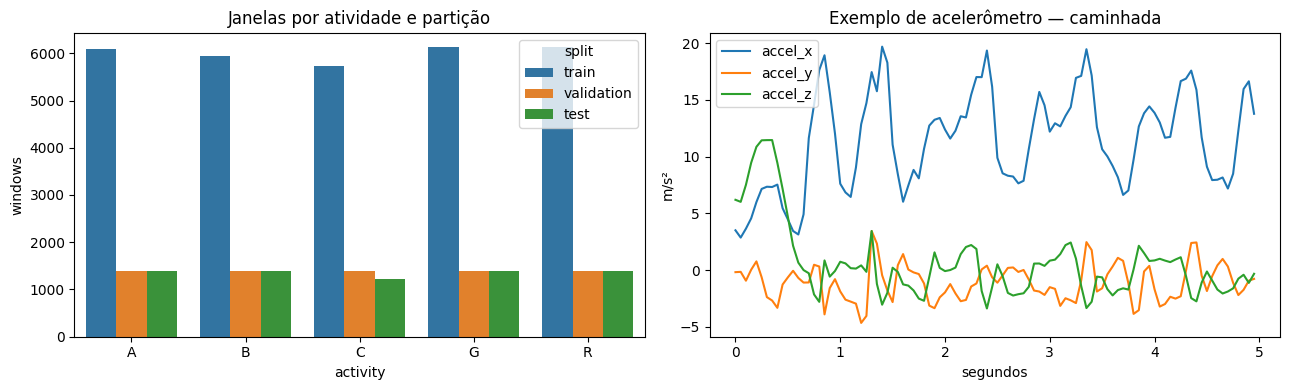

In [ ]:
# Estatísticas calculadas só com o treino para não vazar informação
channel_mean = X_train.mean(axis=(0, 1), dtype=np.float64).astype(np.float32)
channel_std = X_train.std(axis=(0, 1), dtype=np.float64).astype(np.float32)
assert np.all(channel_std > 0)
normalization_table = pd.DataFrame({
    'channel': CHANNELS, 'train_mean': channel_mean, 'train_std': channel_std,
})
display(normalization_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = []
for split_name, labels in [('train', y_train), ('validation', y_val), ('test', y_test)]:
    for index, code in enumerate(ACTIVITY_CODES):
        counts.append({'split': split_name, 'activity': code,
                       'windows': int((labels == index).sum())})
sns.barplot(data=pd.DataFrame(counts), x='activity', y='windows', hue='split', ax=axes[0])
axes[0].set_title('Janelas por atividade e partição')
sample_index = np.flatnonzero(y_train == 0)[0]
axes[1].plot(np.arange(WINDOW_SAMPLES) / SAMPLE_RATE_HZ, X_train[sample_index, :, :3])
axes[1].set(title='Exemplo de acelerômetro — caminhada', xlabel='segundos', ylabel='m/s²')
axes[1].legend(CHANNELS[:3])
plt.tight_layout()
plt.show()


## 6. CNN 1D compacta

A normalização fica dentro do grafo e recebe constantes calculadas apenas no treino. Assim o app fornece valores brutos nas unidades dos sensores e não precisa copiar médias/desvios manualmente.

In [ ]:
# CNN 1D usada no modelo principal
# Entrada 100x6 -> Conv1D -> Pooling -> Conv1D -> GAP -> Dense -> 5 classes
normalizer = tf.keras.layers.Normalization(
    axis=-1, mean=channel_mean, variance=np.square(channel_std),
    name='train_only_normalization',
)
inputs = tf.keras.Input(shape=(WINDOW_SAMPLES, len(CHANNELS)), name='sensor_window')
x = normalizer(inputs)
x = tf.keras.layers.Conv1D(16, 5, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(24, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(len(ACTIVITY_CODES), activation='softmax', name='activity')(x)
model = tf.keras.Model(inputs, outputs, name='wisdm_watch_har')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'],
)
model.summary()

weights = compute_class_weight(
    class_weight='balanced', classes=np.arange(len(ACTIVITY_CODES)), y=y_train,
)
class_weights = {index: float(value) for index, value in enumerate(weights)}
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5,
    ),
]
history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=60, batch_size=128, class_weight=class_weights,
    callbacks=callbacks, verbose=1,
)


Model: "wisdm_watch_har"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window (InputLayer)      │ (None, 100, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ train_only_normalization        │ (None, 100, 6)         │             0 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 24)         │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 24)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,157 (8.43 KB)

 Trainable params: 2,157 (8.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.6019 - loss: 0.9278 - val_accuracy: 0.7937 - val_loss: 0.5220 - learning_rate: 0.0010
Epoch 2/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8230 - loss: 0.4345 - val_accuracy: 0.8271 - val_loss: 0.4168 - learning_rate: 0.0010
Epoch 3/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8668 - loss: 0.3368 - val_accuracy: 0.8473 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 4/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8919 - loss: 0.2866 - val_accuracy: 0.8557 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 5/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9091 - loss: 0.2513 - val_accuracy: 0.8676 - val_loss: 0.3408 - learning_rate: 0.0010
Epoch 6/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9213 - loss: 0.2231 - val_accuracy: 0.8777 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 7/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9302 - loss: 0.1996 

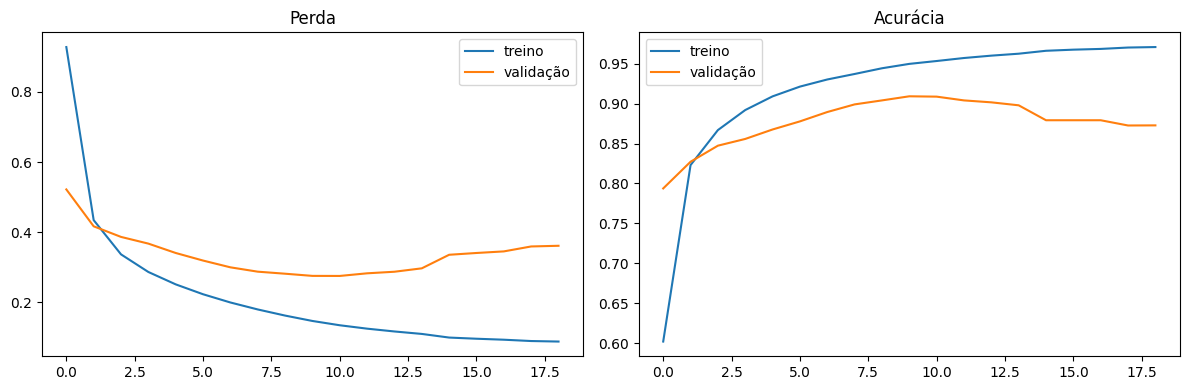

Baseline majoritário accuracy: 0.2055800293685756
Baseline majoritário macro-F1: 0.0682095006090134
Keras accuracy: 0.8397944199706314
Keras macro-F1: 0.8379616136643948
                precision    recall  f1-score   support

       Walking       0.86      0.89      0.88      1401
       Jogging       0.91      1.00      0.95      1384
        Stairs       0.88      0.80      0.84      1225
Brushing Teeth       0.89      0.66      0.76      1400
      Clapping       0.70      0.85      0.77      1400

      accuracy                           0.84      6810
     macro avg       0.85      0.84      0.84      6810
  weighted avg       0.85      0.84      0.84      6810



In [ ]:
# Avaliação do modelo em participantes que não apareceram no treino
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='treino')
axes[0].plot(history.history['val_loss'], label='validação')
axes[0].set_title('Perda'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='treino')
axes[1].plot(history.history['val_accuracy'], label='validação')
axes[1].set_title('Acurácia'); axes[1].legend()
plt.tight_layout(); plt.show()

# O teste é consultado pela primeira vez somente após o treinamento estar encerrado.
majority_class = int(np.bincount(y_train).argmax())
baseline_predictions = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_macro_f1 = f1_score(y_test, baseline_predictions, average='macro')
print('Baseline majoritário accuracy:', baseline_accuracy)
print('Baseline majoritário macro-F1:', baseline_macro_f1)
keras_probabilities = model.predict(X_test, batch_size=256, verbose=0)
keras_predictions = keras_probabilities.argmax(axis=1)
keras_accuracy = accuracy_score(y_test, keras_predictions)
keras_macro_f1 = f1_score(y_test, keras_predictions, average='macro')
print('Keras accuracy:', keras_accuracy)
print('Keras macro-F1:', keras_macro_f1)
print(classification_report(
    y_test, keras_predictions, labels=range(len(ACTIVITY_CODES)),
    target_names=[ACTIVITY_NAMES[c] for c in ACTIVITY_CODES], zero_division=0,
))


## 7. Conversão totalmente `int8`

O conjunto representativo contém apenas janelas do treino. Entrada e saída do arquivo final são `int8`.

In [ ]:
# Quantização pós-treinamento para INT8
# O conjunto representativo vem apenas do treino
representative_rng = np.random.default_rng(SEED)
representative_indices = representative_rng.choice(
    len(X_train), size=min(1000, len(X_train)), replace=False,
)

def representative_dataset():
    for index in representative_indices:
        yield [X_train[index:index + 1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()
print('Tamanho do TFLite int8:', len(tflite_model), 'bytes')

interpreter = tf.lite.Interpreter(model_content=tflite_model, num_threads=2)
interpreter.allocate_tensors()
input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]
print('Entrada:', input_info['shape'], input_info['dtype'], input_info['quantization'])
print('Saída:', output_info['shape'], output_info['dtype'], output_info['quantization'])
assert input_info['shape'].tolist() == [1, WINDOW_SAMPLES, len(CHANNELS)]
assert output_info['shape'].tolist() == [1, len(ACTIVITY_CODES)]
assert input_info['dtype'] == np.int8 and output_info['dtype'] == np.int8


Saved artifact at '/tmp/tmpfcbziob9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='sensor_window')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140399395351312: TensorSpec(shape=(1, 1, 6), dtype=tf.float32, name=None)
  140399395351120: TensorSpec(shape=(1, 1, 6), dtype=tf.float32, name=None)
  140399396114640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395456016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395457552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395455632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395457936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395462352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395456208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395462544: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Tamanho do TFLite int8: 10960 bytes
Entrada: [  1 100   6] <class 'numpy.int8'> (0.5244014859199524, 20)
Saída: [1 5] <class 'numpy.int8'> (0.00390625, -128)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite accuracy: 0.8372980910425845
TFLite macro-F1: 0.8355113952736877
Queda de macro-F1: 0.0024502183907071373
                precision    recall  f1-score   support

       Walking       0.85      0.91      0.88      1401
       Jogging       0.91      1.00      0.95      1384
        Stairs       0.91      0.77      0.83      1225
Brushing Teeth       0.88      0.66      0.75      1400
      Clapping       0.70      0.84      0.76      1400

      accuracy                           0.84      6810
     macro avg       0.85      0.84      0.84      6810
  weighted avg       0.85      0.84      0.84      6810



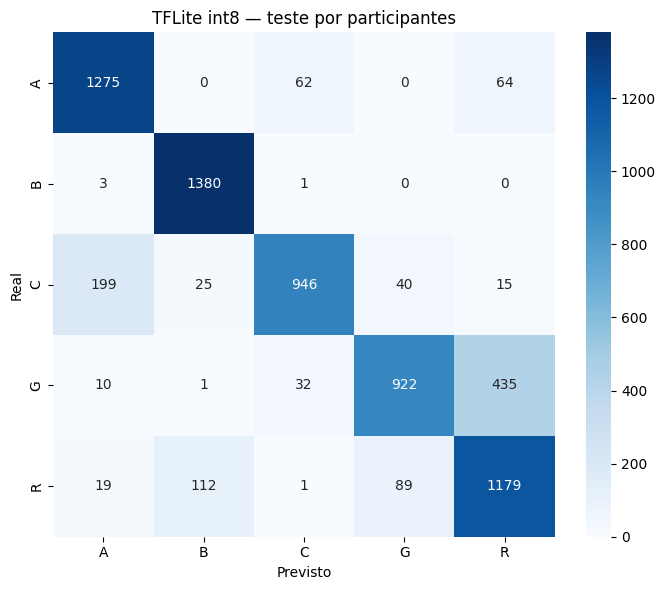

In [ ]:
# Teste do modelo quantizado em INT8
def evaluate_int8(interpreter, X):
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_scale, input_zero = input_detail['quantization']
    output_scale, output_zero = output_detail['quantization']
    assert input_scale > 0 and output_scale > 0
    probabilities = []
    for window in X:
        quantized = np.clip(
            np.rint(window / input_scale + input_zero), -128, 127,
        ).astype(np.int8)[None, ...]
        interpreter.set_tensor(input_detail['index'], quantized)
        interpreter.invoke()
        raw_output = interpreter.get_tensor(output_detail['index'])[0].astype(np.int32)
        output = (raw_output - int(output_zero)) * float(output_scale)
        output = np.maximum(output, 0)
        if output.sum() > 0:
            output /= output.sum()
        probabilities.append(output)
    return np.asarray(probabilities, dtype=np.float32)

tflite_probabilities = evaluate_int8(interpreter, X_test)
tflite_predictions = tflite_probabilities.argmax(axis=1)
tflite_accuracy = accuracy_score(y_test, tflite_predictions)
tflite_macro_f1 = f1_score(y_test, tflite_predictions, average='macro')
tflite_confusion = confusion_matrix(
    y_test, tflite_predictions, labels=range(len(ACTIVITY_CODES)),
)
print('TFLite accuracy:', tflite_accuracy)
print('TFLite macro-F1:', tflite_macro_f1)
print('Queda de macro-F1:', keras_macro_f1 - tflite_macro_f1)
print(classification_report(
    y_test, tflite_predictions, labels=range(len(ACTIVITY_CODES)),
    target_names=[ACTIVITY_NAMES[c] for c in ACTIVITY_CODES], zero_division=0,
))

plt.figure(figsize=(7, 6))
sns.heatmap(
    tflite_confusion, annot=True, fmt='d', cmap='Blues',
    xticklabels=ACTIVITY_CODES, yticklabels=ACTIVITY_CODES,
)
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('TFLite int8 — teste por participantes')
plt.tight_layout(); plt.show()

assert keras_macro_f1 - tflite_macro_f1 <= 0.05, (
    'A quantização perdeu mais de 0,05 de macro-F1; revisar antes de exportar'
)


## 8. Gates finais e pacote de exportação

Os `asserts` abaixo impedem a exportação quando contrato, classes, participantes ou paridade da quantização estiverem incorretos. Macro-F1 abaixo de 0,80 gera um aviso. Caso ajuste de parametros de errado.

In [ ]:
# Estatísticas calculadas só com o treino para não vazar informação
# Conferências finais antes de exportar o modelo.
assert train_set.isdisjoint(val_set | test_set) and val_set.isdisjoint(test_set)
assert set(owner_train).issubset(train_set)
assert set(owner_val).issubset(val_set)
assert set(owner_test).issubset(test_set)
assert set(np.unique(y_train)) == set(range(5))
assert set(np.unique(y_val)) == set(range(5))
assert set(np.unique(y_test)) == set(range(5))
assert np.isfinite(channel_mean).all() and np.isfinite(channel_std).all()
assert set(representative_indices).issubset(set(range(len(X_train))))

if tflite_macro_f1 < 0.80:
    print('ATENÇÃO: macro-F1 abaixo do objetivo de 0,80. Não integrar sem discutir.')
else:
    print('Modelo atingiu o objetivo recomendado de macro-F1 >= 0,80.')

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True)
model_path = EXPORT_DIR / 'wisdm_har_int8.tflite'
model_path.write_bytes(tflite_model)
(EXPORT_DIR / 'labels.txt').write_text(
    '\n'.join(f'{code},{ACTIVITY_NAMES[code]}' for code in ACTIVITY_CODES) + '\n',
    encoding='utf-8',
)

participant_split = {
    'seed': SEED, 'train': train_subjects,
    'validation': val_subjects, 'test': test_subjects,
}
(EXPORT_DIR / 'participant_split.json').write_text(
    json.dumps(participant_split, indent=2), encoding='utf-8',
)

input_scale, input_zero = input_info['quantization']
output_scale, output_zero = output_info['quantization']
contract = {
    'model_file': model_path.name,
    'input_shape': [1, WINDOW_SAMPLES, len(CHANNELS)],
    'input_dtype': 'int8',
    'input_quantization': {'scale': float(input_scale), 'zero_point': int(input_zero)},
    'channels': CHANNELS, 'sample_rate_hz': SAMPLE_RATE_HZ,
    'window_seconds': WINDOW_SECONDS, 'hop_seconds': HOP_SECONDS,
    'max_interpolation_gap_ms': int(MAX_GAP_S * 1000),
    'output_shape': [1, len(ACTIVITY_CODES)], 'output_dtype': 'int8',
    'output_quantization': {'scale': float(output_scale), 'zero_point': int(output_zero)},
    'labels': [{'index': i, 'code': c, 'name': ACTIVITY_NAMES[c]}
               for i, c in enumerate(ACTIVITY_CODES)],
    'normalization_embedded_in_model': True,
}
(EXPORT_DIR / 'model_contract.json').write_text(
    json.dumps(contract, indent=2), encoding='utf-8',
)

metrics = {
    'majority_baseline': {'class_index': majority_class,
                          'accuracy': float(baseline_accuracy),
                          'macro_f1': float(baseline_macro_f1)},
    'keras': {'accuracy': float(keras_accuracy), 'macro_f1': float(keras_macro_f1)},
    'tflite_int8': {'accuracy': float(tflite_accuracy), 'macro_f1': float(tflite_macro_f1),
                    'confusion_matrix': tflite_confusion.tolist()},
    'window_counts': {'train': len(X_train), 'validation': len(X_val), 'test': len(X_test)},
    'model_bytes': len(tflite_model),
    'sha256': hashlib.sha256(tflite_model).hexdigest(),
    'tensorflow_version': tf.__version__,
}
(EXPORT_DIR / 'metrics.json').write_text(
    json.dumps(metrics, indent=2), encoding='utf-8',
)

model_card = f'''# Modelo WISDM Watch HAR

- Classes: {', '.join(ACTIVITY_CODES)}
- Participantes: 35 treino, 8 validação, 8 teste (sem sobreposição)
- Entrada: int8[1,100,6], 20 Hz, 5 segundos
- TFLite accuracy: {tflite_accuracy:.4f}
- TFLite macro-F1: {tflite_macro_f1:.4f}
- Tamanho: {len(tflite_model)} bytes
- SHA-256: {metrics['sha256']}

Limitação: treinado em LG G Watch do WISDM. O Galaxy Watch 6 é outro domínio.
'''
(EXPORT_DIR / 'MODEL_CARD.md').write_text(model_card, encoding='utf-8')

bundle_path = shutil.make_archive(str(WORK_DIR / 'watch_har_export'), 'zip', EXPORT_DIR)
print('Pacote pronto:', bundle_path)
print(json.dumps(metrics, indent=2))


Modelo atingiu o objetivo recomendado de macro-F1 >= 0,80.
Pacote pronto: /content/watch_har/watch_har_export.zip
{
  "majority_baseline": {
    "class_index": 4,
    "accuracy": 0.2055800293685756,
    "macro_f1": 0.0682095006090134
  },
  "keras": {
    "accuracy": 0.8397944199706314,
    "macro_f1": 0.8379616136643948
  },
  "tflite_int8": {
    "accuracy": 0.8372980910425845,
    "macro_f1": 0.8355113952736877,
    "confusion_matrix": [
      [
        1275,
        0,
        62,
        0,
        64
      ],
      [
        3,
        1380,
        1,
        0,
        0
      ],
      [
        199,
        25,
        946,
        40,
        15
      ],
      [
        10,
        1,
        32,
        922,
        435
      ],
      [
        19,
        112,
        1,
        89,
        1179
      ]
    ]
  },
  "window_counts": {
    "train": 30032,
    "validation": 7000,
    "test": 6810
  },
  "model_bytes": 10960,
  "sha256": "bd3c717a8080d04ca3e8a095f5dec09b65fc37

## 9. Experimento comparativo — somente acelerômetro

Para medir o ganho real da fusão de sensores, este experimento mantém exatamente os mesmos participantes, janelas, rótulos e arquitetura do modelo principal, removendo apenas os três canais do giroscópio. Assim, a comparação isola o efeito de usar `accel_x`, `accel_y` e `accel_z` em vez dos seis canais.

As janelas continuam sendo as mesmas geradas na sincronização anterior. Isso torna a comparação direta e evita que diferenças no conjunto de exemplos sejam confundidas com diferenças causadas pelos sensores.


,channel,train_mean,train_std
0,accel_x,0.784441,8.736648
1,accel_y,-3.679922,5.977751
2,accel_z,1.159993,4.801079


Model: "wisdm_watch_har_accel_only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ accelerometer_window            │ (None, 100, 3)         │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ train_only_normalization_accel  │ (None, 100, 3)         │             0 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 24)         │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 24)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,917 (7.49 KB)

 Trainable params: 1,917 (7.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5198 - loss: 1.0834 - val_accuracy: 0.6590 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 2/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7246 - loss: 0.6652 - val_accuracy: 0.7994 - val_loss: 0.5360 - learning_rate: 0.0010
Epoch 3/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7940 - loss: 0.5047 - val_accuracy: 0.8406 - val_loss: 0.4720 - learning_rate: 0.0010
Epoch 4/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8319 - loss: 0.4254 - val_accuracy: 0.8451 - val_loss: 0.4301 - learning_rate: 0.0010
Epoch 5/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8599 - loss: 0.3705 - val_accuracy: 0.8284 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 6/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8791 - loss: 0.3314 - val_accuracy: 0.8230 - val_loss: 0.4110 - learning_rate: 0.0010
Epoch 7/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8908 - loss: 0.3023 -

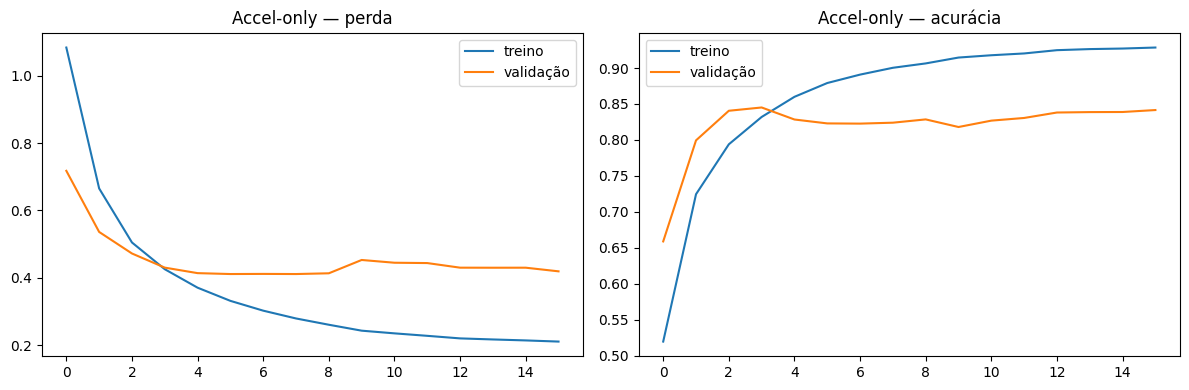

In [ ]:
# CNN 1D usada no modelo principal
# Entrada 100x6 -> Conv1D -> Pooling -> Conv1D -> GAP -> Dense -> 5 classes
# Comparação controlada: mesma janela e mesmo split, usando apenas o acelerômetro.
ACCEL_CHANNELS = CHANNELS[:3]
X_train_accel = X_train[:, :, :3].copy()
X_val_accel = X_val[:, :, :3].copy()
X_test_accel = X_test[:, :, :3].copy()

accel_mean = X_train_accel.mean(axis=(0, 1), dtype=np.float64).astype(np.float32)
accel_std = X_train_accel.std(axis=(0, 1), dtype=np.float64).astype(np.float32)
assert np.all(accel_std > 0)

display(pd.DataFrame({
    'channel': ACCEL_CHANNELS,
    'train_mean': accel_mean,
    'train_std': accel_std,
}))

# Reprodutibilidade do segundo treinamento.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

accel_normalizer = tf.keras.layers.Normalization(
    axis=-1,
    mean=accel_mean,
    variance=np.square(accel_std),
    name='train_only_normalization_accel',
)

accel_inputs = tf.keras.Input(
    shape=(WINDOW_SAMPLES, len(ACCEL_CHANNELS)),
    name='accelerometer_window',
)
x = accel_normalizer(accel_inputs)
x = tf.keras.layers.Conv1D(16, 5, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(24, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
accel_outputs = tf.keras.layers.Dense(
    len(ACTIVITY_CODES), activation='softmax', name='activity'
)(x)

accel_model = tf.keras.Model(
    accel_inputs, accel_outputs, name='wisdm_watch_har_accel_only'
)
accel_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

accel_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5,
    ),
]

accel_model.summary()
accel_history = accel_model.fit(
    X_train_accel,
    y_train,
    validation_data=(X_val_accel, y_val),
    epochs=60,
    batch_size=128,
    class_weight=class_weights,
    callbacks=accel_callbacks,
    verbose=1,
)

accel_keras_probabilities = accel_model.predict(
    X_test_accel, batch_size=256, verbose=0
)
accel_keras_predictions = accel_keras_probabilities.argmax(axis=1)
accel_keras_accuracy = accuracy_score(y_test, accel_keras_predictions)
accel_keras_macro_f1 = f1_score(
    y_test, accel_keras_predictions, average='macro'
)

print('Accel-only Keras accuracy:', accel_keras_accuracy)
print('Accel-only Keras macro-F1:', accel_keras_macro_f1)
print(classification_report(
    y_test,
    accel_keras_predictions,
    labels=range(len(ACTIVITY_CODES)),
    target_names=[ACTIVITY_NAMES[c] for c in ACTIVITY_CODES],
    zero_division=0,
))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(accel_history.history['loss'], label='treino')
axes[0].plot(accel_history.history['val_loss'], label='validação')
axes[0].set_title('Accel-only — perda')
axes[0].legend()
axes[1].plot(accel_history.history['accuracy'], label='treino')
axes[1].plot(accel_history.history['val_accuracy'], label='validação')
axes[1].set_title('Accel-only — acurácia')
axes[1].legend()
plt.tight_layout()
plt.show()


## 10. Quantização `int8` do modelo somente com acelerômetro

O segundo modelo é quantizado com o mesmo procedimento do modelo principal. O conjunto representativo usa somente janelas de treino e a inferência final também é validada sobre os participantes de teste.


Saved artifact at '/tmp/tmpz_t8obzl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 3), dtype=tf.float32, name='accelerometer_window')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140399395340944: TensorSpec(shape=(1, 1, 3), dtype=tf.float32, name=None)
  140399395340752: TensorSpec(shape=(1, 1, 3), dtype=tf.float32, name=None)
  140399688958416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395342864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395340368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395344400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395341520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395344592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395341328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395352464: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Tamanho do TFLite int8 accel-only: 11360 bytes
Entrada: [  1 100   3] <class 'numpy.int8'> (0.5244014859199524, 20)
Saída: [1 5] <class 'numpy.int8'> (0.00390625, -128)
Accel-only TFLite accuracy: 0.720704845814978
Accel-only TFLite macro-F1: 0.7185254651372852
Queda de macro-F1 após quantização: -0.004781800515671231
                precision    recall  f1-score   support

       Walking       0.54      0.70      0.61      1401
       Jogging       0.87      0.99      0.93      1384
        Stairs       0.64      0.62      0.63      1225
Brushing Teeth       0.85      0.67      0.75      1400
      Clapping       0.76      0.61      0.67      1400

      accuracy                           0.72      6810
     macro avg       0.73      0.72      0.72      6810
  weighted avg       0.73      0.72      0.72      6810



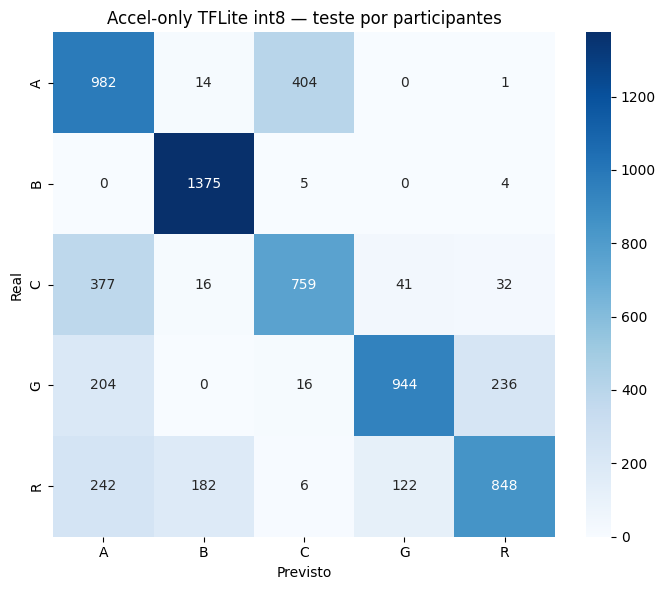

In [ ]:
# Quantização e teste da versão com apenas acelerômetro
accel_representative_rng = np.random.default_rng(SEED)
accel_representative_indices = accel_representative_rng.choice(
    len(X_train_accel),
    size=min(1000, len(X_train_accel)),
    replace=False,
)

def accel_representative_dataset():
    for index in accel_representative_indices:
        yield [X_train_accel[index:index + 1].astype(np.float32)]

accel_converter = tf.lite.TFLiteConverter.from_keras_model(accel_model)
accel_converter.optimizations = [tf.lite.Optimize.DEFAULT]
accel_converter.representative_dataset = accel_representative_dataset
accel_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]
accel_converter.inference_input_type = tf.int8
accel_converter.inference_output_type = tf.int8
accel_tflite_model = accel_converter.convert()

accel_interpreter = tf.lite.Interpreter(
    model_content=accel_tflite_model, num_threads=2
)
accel_interpreter.allocate_tensors()
accel_input_info = accel_interpreter.get_input_details()[0]
accel_output_info = accel_interpreter.get_output_details()[0]

print('Tamanho do TFLite int8 accel-only:', len(accel_tflite_model), 'bytes')
print(
    'Entrada:',
    accel_input_info['shape'],
    accel_input_info['dtype'],
    accel_input_info['quantization'],
)
print(
    'Saída:',
    accel_output_info['shape'],
    accel_output_info['dtype'],
    accel_output_info['quantization'],
)

assert accel_input_info['shape'].tolist() == [
    1, WINDOW_SAMPLES, len(ACCEL_CHANNELS)
]
assert accel_output_info['shape'].tolist() == [1, len(ACTIVITY_CODES)]
assert accel_input_info['dtype'] == np.int8
assert accel_output_info['dtype'] == np.int8
assert set(accel_representative_indices).issubset(
    set(range(len(X_train_accel)))
)

accel_tflite_probabilities = evaluate_int8(
    accel_interpreter, X_test_accel
)
accel_tflite_predictions = accel_tflite_probabilities.argmax(axis=1)
accel_tflite_accuracy = accuracy_score(
    y_test, accel_tflite_predictions
)
accel_tflite_macro_f1 = f1_score(
    y_test, accel_tflite_predictions, average='macro'
)
accel_tflite_confusion = confusion_matrix(
    y_test,
    accel_tflite_predictions,
    labels=range(len(ACTIVITY_CODES)),
)

print('Accel-only TFLite accuracy:', accel_tflite_accuracy)
print('Accel-only TFLite macro-F1:', accel_tflite_macro_f1)
print(
    'Queda de macro-F1 após quantização:',
    accel_keras_macro_f1 - accel_tflite_macro_f1,
)
print(classification_report(
    y_test,
    accel_tflite_predictions,
    labels=range(len(ACTIVITY_CODES)),
    target_names=[ACTIVITY_NAMES[c] for c in ACTIVITY_CODES],
    zero_division=0,
))

plt.figure(figsize=(7, 6))
sns.heatmap(
    accel_tflite_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=ACTIVITY_CODES,
    yticklabels=ACTIVITY_CODES,
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Accel-only TFLite int8 — teste por participantes')
plt.tight_layout()
plt.show()


## 11. Comparação final e decisão para o embarque

A tabela abaixo compara os dois modelos quantizados sobre o mesmo conjunto de teste. O objetivo é registrar o custo e o benefício de incluir o giroscópio no aplicativo Wear OS.

A decisão de embarque deve considerar simultaneamente desempenho, tamanho do modelo e complexidade de aquisição dos sensores. O resultado no WISDM não substitui a validação no Galaxy Watch 6, pois o relógio do conjunto original é de outro domínio de hardware.


,modelo,sensores,canais,input_shape,accuracy_int8,macro_f1_int8,tamanho_bytes,tamanho_kb
0,Accel only,Acelerômetro,3,1x100x3,0.720705,0.718525,11360,11.093750
1,Accel + Gyro,Acelerômetro + Giroscópio,6,1x100x6,0.837298,0.835511,10960,10.703125


Ganho de macro-F1 com Accel+Gyro: +0.1170
Ganho de accuracy com Accel+Gyro: +0.1166


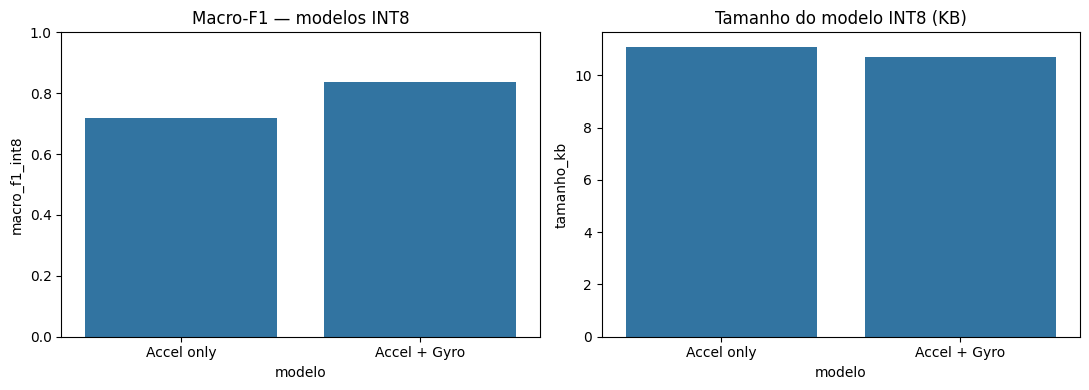

Pacote atualizado: /content/watch_har/watch_har_export.zip


In [ ]:
# Comparação final entre Accel-only e Accel + Gyro
comparison = pd.DataFrame([
    {
        'modelo': 'Accel only',
        'sensores': 'Acelerômetro',
        'canais': 3,
        'input_shape': f'1x{WINDOW_SAMPLES}x3',
        'accuracy_int8': float(accel_tflite_accuracy),
        'macro_f1_int8': float(accel_tflite_macro_f1),
        'tamanho_bytes': int(len(accel_tflite_model)),
    },
    {
        'modelo': 'Accel + Gyro',
        'sensores': 'Acelerômetro + Giroscópio',
        'canais': 6,
        'input_shape': f'1x{WINDOW_SAMPLES}x6',
        'accuracy_int8': float(tflite_accuracy),
        'macro_f1_int8': float(tflite_macro_f1),
        'tamanho_bytes': int(len(tflite_model)),
    },
])

comparison['tamanho_kb'] = comparison['tamanho_bytes'] / 1024
display(comparison)

fusion_gain_f1 = float(
    tflite_macro_f1 - accel_tflite_macro_f1
)
fusion_gain_accuracy = float(
    tflite_accuracy - accel_tflite_accuracy
)
print(
    'Ganho de macro-F1 com Accel+Gyro:',
    f'{fusion_gain_f1:+.4f}',
)
print(
    'Ganho de accuracy com Accel+Gyro:',
    f'{fusion_gain_accuracy:+.4f}',
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(
    data=comparison,
    x='modelo',
    y='macro_f1_int8',
    ax=axes[0],
)
axes[0].set_ylim(0, 1)
axes[0].set_title('Macro-F1 — modelos INT8')
sns.barplot(
    data=comparison,
    x='modelo',
    y='tamanho_kb',
    ax=axes[1],
)
axes[1].set_title('Tamanho do modelo INT8 (KB)')
plt.tight_layout()
plt.show()

# Exporta o segundo modelo e os arquivos de comparação.
accel_model_path = EXPORT_DIR / 'wisdm_har_accel_int8.tflite'
accel_model_path.write_bytes(accel_tflite_model)

accel_input_scale, accel_input_zero = accel_input_info['quantization']
accel_output_scale, accel_output_zero = accel_output_info['quantization']

accel_contract = {
    'model_file': accel_model_path.name,
    'input_shape': [1, WINDOW_SAMPLES, len(ACCEL_CHANNELS)],
    'input_dtype': 'int8',
    'input_quantization': {
        'scale': float(accel_input_scale),
        'zero_point': int(accel_input_zero),
    },
    'channels': ACCEL_CHANNELS,
    'sample_rate_hz': SAMPLE_RATE_HZ,
    'window_seconds': WINDOW_SECONDS,
    'hop_seconds': HOP_SECONDS,
    'output_shape': [1, len(ACTIVITY_CODES)],
    'output_dtype': 'int8',
    'output_quantization': {
        'scale': float(accel_output_scale),
        'zero_point': int(accel_output_zero),
    },
    'labels': [
        {'index': i, 'code': c, 'name': ACTIVITY_NAMES[c]}
        for i, c in enumerate(ACTIVITY_CODES)
    ],
    'normalization_embedded_in_model': True,
}
(EXPORT_DIR / 'model_contract_accel_only.json').write_text(
    json.dumps(accel_contract, indent=2),
    encoding='utf-8',
)

accel_metrics = {
    'keras': {
        'accuracy': float(accel_keras_accuracy),
        'macro_f1': float(accel_keras_macro_f1),
    },
    'tflite_int8': {
        'accuracy': float(accel_tflite_accuracy),
        'macro_f1': float(accel_tflite_macro_f1),
        'confusion_matrix': accel_tflite_confusion.tolist(),
    },
    'model_bytes': len(accel_tflite_model),
    'sha256': hashlib.sha256(accel_tflite_model).hexdigest(),
}
(EXPORT_DIR / 'metrics_accel_only.json').write_text(
    json.dumps(accel_metrics, indent=2),
    encoding='utf-8',
)

comparison.to_csv(
    EXPORT_DIR / 'model_comparison.csv', index=False
)
(EXPORT_DIR / 'model_comparison.json').write_text(
    comparison.to_json(orient='records', indent=2),
    encoding='utf-8',
)

decision_summary = {
    'macro_f1_gain_accel_plus_gyro': fusion_gain_f1,
    'accuracy_gain_accel_plus_gyro': fusion_gain_accuracy,
    'note': (
        'A escolha final deve considerar também o teste real '
        'no Galaxy Watch 6.'
    ),
}
(EXPORT_DIR / 'deployment_decision.json').write_text(
    json.dumps(decision_summary, indent=2),
    encoding='utf-8',
)

# Atualiza o pacote ZIP para incluir o experimento comparativo.
bundle_path = shutil.make_archive(
    str(WORK_DIR / 'watch_har_export'),
    'zip',
    EXPORT_DIR,
)
print('Pacote atualizado:', bundle_path)


## 12. Contrato de integração com o Galaxy Watch 6

Para reproduzir a entrada do modelo principal no Wear OS, o aplicativo deve manter a mesma convenção usada no treinamento:

- frequência-alvo: **20 Hz**;
- janela: **5 segundos**;
- tamanho: **100 amostras**;
- avanço entre inferências: **1 segundo**;
- modelo principal: `accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z`;
- modelo alternativo: `accel_x, accel_y, accel_z`;
- unidades esperadas pelo pipeline: acelerômetro em **m/s²** e giroscópio em **rad/s**;
- entrada e saída do arquivo final: **int8**;
- normalização: incorporada ao próprio modelo.

No aplicativo, acelerômetro e giroscópio não devem ser tratados como se cada evento de um sensor tivesse necessariamente um evento simultâneo no outro. Para o modelo de seis canais, os buffers devem preservar os timestamps e produzir uma janela temporal compatível com a reamostragem utilizada no notebook.

A avaliação em dispositivo deve ser registrada separadamente da avaliação do WISDM. O resultado de teste do notebook mede generalização para participantes não vistos dentro do domínio do conjunto de dados; o Galaxy Watch 6 constitui um novo domínio de hardware.


In [ ]:
# Informações que o app Wear OS precisa seguir para usar o modelo corretamente
wear_os_contract = {
    'target_device': 'Galaxy Watch 6',
    'sample_rate_hz': SAMPLE_RATE_HZ,
    'sample_period_ms': int(1000 / SAMPLE_RATE_HZ),
    'window_seconds': WINDOW_SECONDS,
    'window_samples': WINDOW_SAMPLES,
    'hop_seconds': HOP_SECONDS,
    'models': {
        'accel_gyro': {
            'file': 'wisdm_har_int8.tflite',
            'channels': CHANNELS,
            'input_shape': [1, WINDOW_SAMPLES, len(CHANNELS)],
        },
        'accel_only': {
            'file': 'wisdm_har_accel_int8.tflite',
            'channels': ACCEL_CHANNELS,
            'input_shape': [1, WINDOW_SAMPLES, len(ACCEL_CHANNELS)],
        },
    },
    'sensor_units': {
        'accelerometer': 'm/s^2',
        'gyroscope': 'rad/s',
    },
    'runtime_notes': [
        'Preservar timestamps dos eventos de sensor.',
        'No modelo de seis canais, alinhar accel e gyro na mesma grade temporal.',
        'Executar nova inferência a cada HOP_SECONDS após a primeira janela completa.',
        'Registrar testes reais no Galaxy Watch 6 separadamente das métricas WISDM.',
    ],
}

(EXPORT_DIR / 'wear_os_contract.json').write_text(
    json.dumps(wear_os_contract, indent=2),
    encoding='utf-8',
)

bundle_path = shutil.make_archive(
    str(WORK_DIR / 'watch_har_export'),
    'zip',
    EXPORT_DIR,
)
print('Contrato Wear OS salvo em:', EXPORT_DIR / 'wear_os_contract.json')
print('Pacote final atualizado:', bundle_path)


Contrato Wear OS salvo em: /content/watch_har/export/wear_os_contract.json
Pacote final atualizado: /content/watch_har/watch_har_export.zip


## 13. TFLite FP32 × TFLite INT8 — impacto real da quantização

O modelo principal com acelerômetro + giroscópio também é convertido para **TFLite FP32**, sem quantização.  
Assim, a comparação é feita entre dois artefatos TFLite derivados da mesma CNN e avaliados sobre exatamente o mesmo conjunto de teste.

São comparados:

- tamanho do arquivo;
- accuracy;
- macro-F1;
- redução percentual de tamanho;
- variação de desempenho após a quantização.

O objetivo é demonstrar quantitativamente se a compactação INT8 trouxe economia sem degradar de forma relevante a classificação.


Saved artifact at '/tmp/tmpiz6jsdym'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='sensor_window')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140399395351312: TensorSpec(shape=(1, 1, 6), dtype=tf.float32, name=None)
  140399395351120: TensorSpec(shape=(1, 1, 6), dtype=tf.float32, name=None)
  140399396114640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395456016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395457552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395455632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395457936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395462352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395456208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140399395462544: TensorSpec(shape=(), dtype=tf.resource, name=None)
Tamanho 

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,formato,dtype_entrada,accuracy,macro_f1,tamanho_bytes,tamanho_kb
0,TFLite FP32,float32,0.839794,0.837962,15008,14.656250
1,TFLite INT8,int8,0.837298,0.835511,10960,10.703125


Redução de tamanho FP32 -> INT8: 26.97%
Variação de accuracy: -0.250 p.p.
Variação de macro-F1: -0.0025


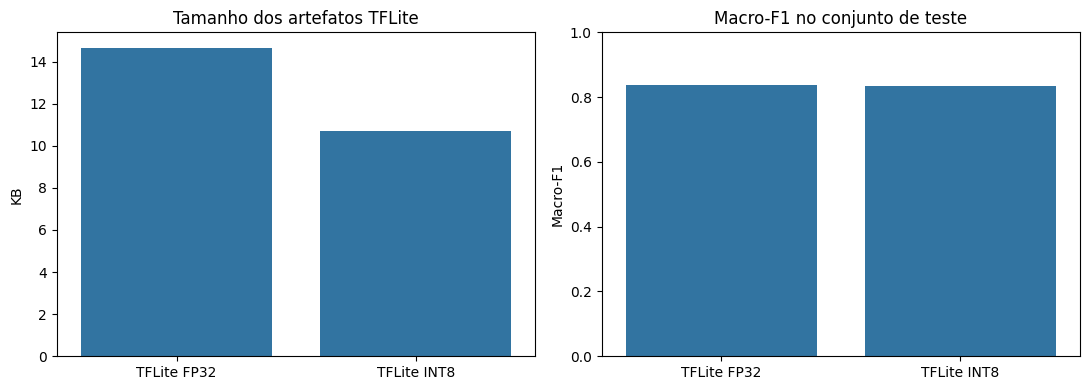

In [ ]:
# Comparação entre TFLite FP32 e TFLite INT8
# Conversão do modelo principal para TFLite FP32 (sem quantização).
fp32_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_fp32_model = fp32_converter.convert()

fp32_model_path = EXPORT_DIR / 'wisdm_har_fp32.tflite'
fp32_model_path.write_bytes(tflite_fp32_model)

fp32_interpreter = tf.lite.Interpreter(
    model_content=tflite_fp32_model,
    num_threads=2,
)
fp32_interpreter.allocate_tensors()

fp32_input_info = fp32_interpreter.get_input_details()[0]
fp32_output_info = fp32_interpreter.get_output_details()[0]

print('Tamanho do TFLite FP32:', len(tflite_fp32_model), 'bytes')
print('Entrada FP32:', fp32_input_info['shape'], fp32_input_info['dtype'])
print('Saída FP32:', fp32_output_info['shape'], fp32_output_info['dtype'])

assert fp32_input_info['shape'].tolist() == [
    1, WINDOW_SAMPLES, len(CHANNELS)
]
assert fp32_output_info['shape'].tolist() == [1, len(ACTIVITY_CODES)]
assert fp32_input_info['dtype'] == np.float32
assert fp32_output_info['dtype'] == np.float32

def evaluate_fp32_tflite(interpreter, X):
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    probabilities = []

    for window in X:
        tensor = window.astype(np.float32, copy=False)[None, ...]
        interpreter.set_tensor(input_detail['index'], tensor)
        interpreter.invoke()
        output = interpreter.get_tensor(output_detail['index'])[0]
        probabilities.append(output)

    return np.asarray(probabilities, dtype=np.float32)

fp32_tflite_probabilities = evaluate_fp32_tflite(
    fp32_interpreter, X_test
)
fp32_tflite_predictions = fp32_tflite_probabilities.argmax(axis=1)

fp32_tflite_accuracy = accuracy_score(
    y_test, fp32_tflite_predictions
)
fp32_tflite_macro_f1 = f1_score(
    y_test, fp32_tflite_predictions, average='macro'
)

size_reduction_pct = (
    1 - len(tflite_model) / len(tflite_fp32_model)
) * 100.0

accuracy_delta_pp = (
    tflite_accuracy - fp32_tflite_accuracy
) * 100.0

macro_f1_delta = (
    tflite_macro_f1 - fp32_tflite_macro_f1
)

compression_comparison = pd.DataFrame([
    {
        'formato': 'TFLite FP32',
        'dtype_entrada': 'float32',
        'accuracy': float(fp32_tflite_accuracy),
        'macro_f1': float(fp32_tflite_macro_f1),
        'tamanho_bytes': int(len(tflite_fp32_model)),
        'tamanho_kb': float(len(tflite_fp32_model) / 1024),
    },
    {
        'formato': 'TFLite INT8',
        'dtype_entrada': 'int8',
        'accuracy': float(tflite_accuracy),
        'macro_f1': float(tflite_macro_f1),
        'tamanho_bytes': int(len(tflite_model)),
        'tamanho_kb': float(len(tflite_model) / 1024),
    },
])

display(compression_comparison)

print(f'Redução de tamanho FP32 -> INT8: {size_reduction_pct:.2f}%')
print(f'Variação de accuracy: {accuracy_delta_pp:+.3f} p.p.')
print(f'Variação de macro-F1: {macro_f1_delta:+.4f}')

compression_comparison.to_csv(
    EXPORT_DIR / 'tflite_fp32_vs_int8.csv',
    index=False,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(
    data=compression_comparison,
    x='formato',
    y='tamanho_kb',
    ax=axes[0],
)
axes[0].set_title('Tamanho dos artefatos TFLite')
axes[0].set_ylabel('KB')
axes[0].set_xlabel('')

sns.barplot(
    data=compression_comparison,
    x='formato',
    y='macro_f1',
    ax=axes[1],
)
axes[1].set_ylim(0, 1)
axes[1].set_title('Macro-F1 no conjunto de teste')
axes[1].set_ylabel('Macro-F1')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(
    EXPORT_DIR / 'tflite_fp32_vs_int8.png',
    dpi=180,
    bbox_inches='tight',
)
plt.show()


## 14. Benchmark de inferência no Colab

Este benchmark mede o custo de inferência dos modelos **TFLite FP32** e **TFLite INT8** em CPU do ambiente Colab.

São medidos dois tempos:

- **invoke_ms**: somente a chamada de inferência do runtime;
- **end_to_end_ms**: preparação da entrada + envio ao tensor + inferência + leitura da saída.

Para o modelo INT8, o tempo `end_to_end_ms` inclui a quantização da janela de entrada.  
Os resultados deste benchmark **não representam a latência do Galaxy Watch 6**. A medição em dispositivo deve ser feita separadamente após a integração no Wear OS.


,modelo,amostras,invoke_media_ms,invoke_mediana_ms,invoke_p95_ms,invoke_std_ms,e2e_media_ms,e2e_mediana_ms,e2e_p95_ms,e2e_std_ms
0,TFLite FP32,1000,0.013856,0.013365,0.016921,0.003186,0.019187,0.018513,0.024050,0.003724
1,TFLite INT8,1000,0.015856,0.015218,0.020246,0.002857,0.040564,0.039088,0.051637,0.004742


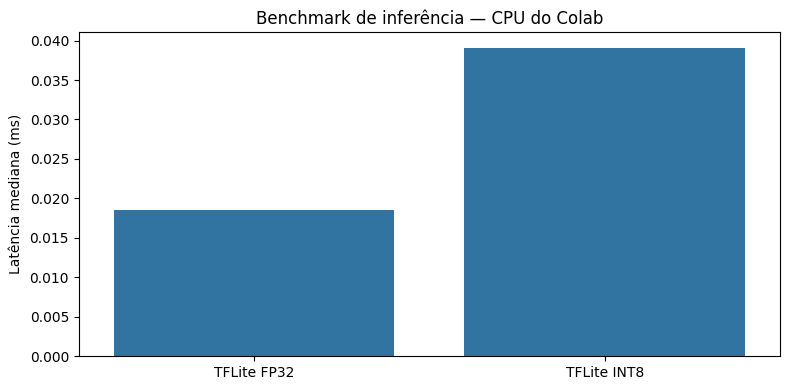

Observação: estes tempos caracterizam apenas o ambiente Colab. A latência real deve ser medida novamente no Galaxy Watch 6.


In [ ]:
# Benchmark no Colab para comparar o tempo de inferência
# Esses tempos não representam o Galaxy Watch 6
import time

def _prepare_tflite_input(window, input_detail):
    dtype = input_detail['dtype']

    if dtype == np.int8:
        scale, zero_point = input_detail['quantization']
        assert scale > 0
        return np.clip(
            np.rint(window / scale + zero_point),
            -128,
            127,
        ).astype(np.int8)[None, ...]

    return window.astype(np.float32, copy=False)[None, ...]

def benchmark_tflite(
    interpreter,
    X,
    model_name,
    sample_count=1000,
    warmup=50,
):
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]

    n = min(sample_count, len(X))
    warmup_n = min(warmup, n)

    # Warm-up para reduzir o efeito da inicialização do runtime.
    for i in range(warmup_n):
        tensor = _prepare_tflite_input(X[i], input_detail)
        interpreter.set_tensor(input_detail['index'], tensor)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_detail['index'])

    invoke_times_ms = []
    end_to_end_times_ms = []

    for i in range(n):
        total_start = time.perf_counter_ns()

        tensor = _prepare_tflite_input(X[i], input_detail)
        interpreter.set_tensor(input_detail['index'], tensor)

        invoke_start = time.perf_counter_ns()
        interpreter.invoke()
        invoke_end = time.perf_counter_ns()

        _ = interpreter.get_tensor(output_detail['index'])
        total_end = time.perf_counter_ns()

        invoke_times_ms.append(
            (invoke_end - invoke_start) / 1_000_000
        )
        end_to_end_times_ms.append(
            (total_end - total_start) / 1_000_000
        )

    invoke_times_ms = np.asarray(invoke_times_ms, dtype=np.float64)
    end_to_end_times_ms = np.asarray(
        end_to_end_times_ms, dtype=np.float64
    )

    return {
        'modelo': model_name,
        'amostras': int(n),
        'invoke_media_ms': float(invoke_times_ms.mean()),
        'invoke_mediana_ms': float(np.median(invoke_times_ms)),
        'invoke_p95_ms': float(np.percentile(invoke_times_ms, 95)),
        'invoke_std_ms': float(invoke_times_ms.std()),
        'e2e_media_ms': float(end_to_end_times_ms.mean()),
        'e2e_mediana_ms': float(np.median(end_to_end_times_ms)),
        'e2e_p95_ms': float(np.percentile(end_to_end_times_ms, 95)),
        'e2e_std_ms': float(end_to_end_times_ms.std()),
    }

benchmark_results = pd.DataFrame([
    benchmark_tflite(
        fp32_interpreter,
        X_test,
        'TFLite FP32',
    ),
    benchmark_tflite(
        interpreter,
        X_test,
        'TFLite INT8',
    ),
])

display(benchmark_results)

benchmark_results.to_csv(
    EXPORT_DIR / 'benchmark_inferencia_colab.csv',
    index=False,
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=benchmark_results,
    x='modelo',
    y='e2e_mediana_ms',
)
plt.ylabel('Latência mediana (ms)')
plt.xlabel('')
plt.title('Benchmark de inferência — CPU do Colab')
plt.tight_layout()
plt.savefig(
    EXPORT_DIR / 'benchmark_inferencia_colab.png',
    dpi=180,
    bbox_inches='tight',
)
plt.show()

print(
    'Observação: estes tempos caracterizam apenas o ambiente Colab. '
    'A latência real deve ser medida novamente no Galaxy Watch 6.'
)


## 15. Matriz de confusão normalizada e métricas por classe

A matriz de confusão absoluta mostra quantas janelas foram classificadas em cada combinação de classe real e prevista.  
Para facilitar a interpretação, esta seção apresenta também a matriz **normalizada por classe real**, em porcentagem.

Além disso, são consolidadas `precision`, `recall`, `F1-score` e suporte para cada atividade.  
Esses resultados ajudam a identificar quais classes são mais robustas e onde o modelo ainda apresenta confusões sistemáticas.


,atividade,precision,recall,f1_score,support
0,Walking,0.8466,0.9101,0.8772,1401
1,Jogging,0.9091,0.9971,0.9511,1384
2,Stairs,0.9079,0.7722,0.8346,1225
3,Brushing Teeth,0.8773,0.6586,0.7523,1400
4,Clapping,0.6964,0.8421,0.7624,1400


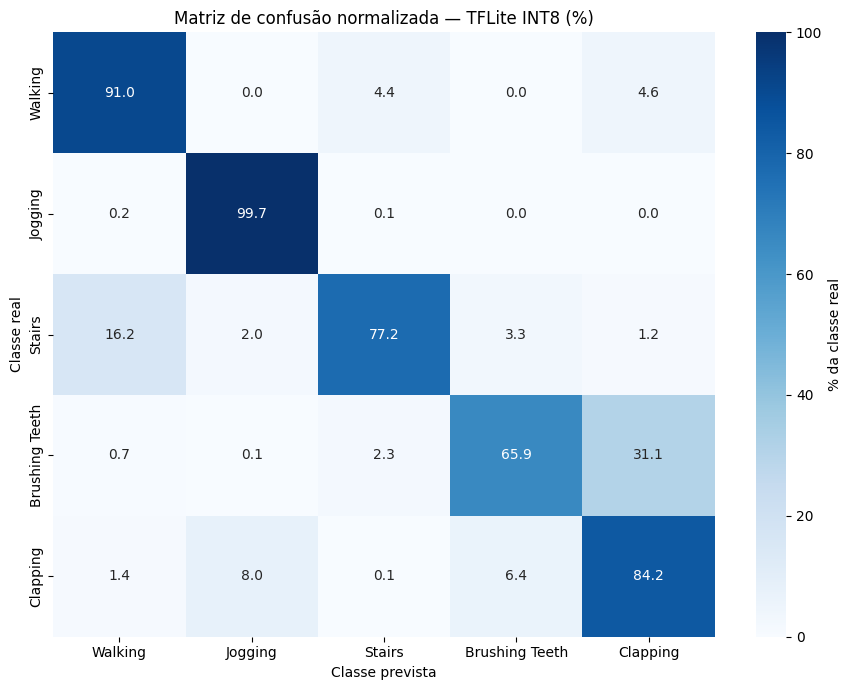

Principais confusões do modelo:


,classe_real,classe_prevista,erros,percentual_da_classe_real
0,Brushing Teeth,Clapping,435,31.071429
1,Stairs,Walking,199,16.244898
2,Clapping,Jogging,112,8.000000
3,Clapping,Brushing Teeth,89,6.357143
4,Walking,Clapping,64,4.568166
5,Walking,Stairs,62,4.425410
6,Stairs,Brushing Teeth,40,3.265306
7,Brushing Teeth,Stairs,32,2.285714
8,Stairs,Jogging,25,2.040816
9,Clapping,Walking,19,1.357143


In [ ]:
# Matriz de confusão em porcentagem e métricas por atividade
from sklearn.metrics import precision_recall_fscore_support

class_names = [
    ACTIVITY_NAMES[c] for c in ACTIVITY_CODES
]

normalized_confusion = confusion_matrix(
    y_test,
    tflite_predictions,
    labels=range(len(ACTIVITY_CODES)),
    normalize='true',
) * 100.0

normalized_confusion_df = pd.DataFrame(
    normalized_confusion,
    index=class_names,
    columns=class_names,
)

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    tflite_predictions,
    labels=range(len(ACTIVITY_CODES)),
    zero_division=0,
)

per_class_metrics = pd.DataFrame({
    'atividade': class_names,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'support': support,
})

display(per_class_metrics.round({
    'precision': 4,
    'recall': 4,
    'f1_score': 4,
}))

plt.figure(figsize=(9, 7))
sns.heatmap(
    normalized_confusion_df,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=100,
    cbar_kws={'label': '% da classe real'},
)
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.title('Matriz de confusão normalizada — TFLite INT8 (%)')
plt.tight_layout()
plt.savefig(
    EXPORT_DIR / 'confusion_matrix_int8_normalizada.png',
    dpi=180,
    bbox_inches='tight',
)
plt.show()

normalized_confusion_df.to_csv(
    EXPORT_DIR / 'confusion_matrix_int8_normalizada.csv',
)
per_class_metrics.to_csv(
    EXPORT_DIR / 'metricas_por_classe_int8.csv',
    index=False,
)

# Principais confusões fora da diagonal.
errors = []
for real_idx, real_name in enumerate(class_names):
    for pred_idx, pred_name in enumerate(class_names):
        if real_idx == pred_idx:
            continue
        count = int(tflite_confusion[real_idx, pred_idx])
        pct = float(normalized_confusion[real_idx, pred_idx])
        if count > 0:
            errors.append({
                'classe_real': real_name,
                'classe_prevista': pred_name,
                'erros': count,
                'percentual_da_classe_real': pct,
            })

top_confusions = (
    pd.DataFrame(errors)
    .sort_values('erros', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Principais confusões do modelo:')
display(top_confusions)

top_confusions.to_csv(
    EXPORT_DIR / 'principais_confusoes_int8.csv',
    index=False,
)


## 16. Consolidação dos artefatos finais

As novas análises são adicionadas ao pacote de exportação para manter no mesmo ZIP:

- modelo TFLite FP32 de referência;
- modelo TFLite INT8 selecionado;
- comparação de compactação;
- benchmark de inferência no Colab;
- matriz de confusão normalizada;
- métricas por classe;
- principais confusões;
- contratos e métricas já produzidos anteriormente.

O `.tflite` INT8 com acelerômetro + giroscópio continua sendo o modelo indicado para a integração no Galaxy Watch 6.


In [ ]:
# Atualiza os arquivos finais e recria o pacote de exportação
# Atualiza metrics.json com as novas análises.
metrics_path = EXPORT_DIR / 'metrics.json'

if metrics_path.exists():
    consolidated_metrics = json.loads(
        metrics_path.read_text(encoding='utf-8')
    )
else:
    consolidated_metrics = {}

consolidated_metrics['tflite_fp32'] = {
    'accuracy': float(fp32_tflite_accuracy),
    'macro_f1': float(fp32_tflite_macro_f1),
    'model_bytes': int(len(tflite_fp32_model)),
}

consolidated_metrics['compression_fp32_to_int8'] = {
    'size_reduction_pct': float(size_reduction_pct),
    'accuracy_delta_pp': float(accuracy_delta_pp),
    'macro_f1_delta': float(macro_f1_delta),
}

consolidated_metrics['benchmark_colab'] = (
    benchmark_results.to_dict(orient='records')
)

consolidated_metrics['per_class_int8'] = (
    per_class_metrics.to_dict(orient='records')
)

metrics_path.write_text(
    json.dumps(
        consolidated_metrics,
        indent=2,
        ensure_ascii=False,
    ),
    encoding='utf-8',
)

# Atualiza o Model Card sem duplicar a seção em reexecuções.
model_card_path = EXPORT_DIR / 'MODEL_CARD.md'
if model_card_path.exists():
    model_card_text = model_card_path.read_text(encoding='utf-8')
else:
    model_card_text = '# Modelo WISDM Watch HAR\n'

marker = '\n## Análises adicionais\n'
if marker in model_card_text:
    model_card_text = model_card_text.split(marker)[0].rstrip() + '\n'

model_card_text += f'''
## Análises adicionais

- TFLite FP32: accuracy {fp32_tflite_accuracy:.4f}; macro-F1 {fp32_tflite_macro_f1:.4f}; {len(tflite_fp32_model)} bytes
- TFLite INT8: accuracy {tflite_accuracy:.4f}; macro-F1 {tflite_macro_f1:.4f}; {len(tflite_model)} bytes
- Redução de tamanho FP32 -> INT8: {size_reduction_pct:.2f}%
- Variação de accuracy após INT8: {accuracy_delta_pp:+.3f} p.p.
- Benchmark de latência: executado em CPU do Colab; não representa o Galaxy Watch 6.
'''

model_card_path.write_text(
    model_card_text,
    encoding='utf-8',
)

bundle_path = shutil.make_archive(
    str(WORK_DIR / 'watch_har_export'),
    'zip',
    EXPORT_DIR,
)

print('Pacote final atualizado:', bundle_path)
print('Arquivos adicionados:')
for name in [
    'wisdm_har_fp32.tflite',
    'tflite_fp32_vs_int8.csv',
    'tflite_fp32_vs_int8.png',
    'benchmark_inferencia_colab.csv',
    'benchmark_inferencia_colab.png',
    'confusion_matrix_int8_normalizada.csv',
    'confusion_matrix_int8_normalizada.png',
    'metricas_por_classe_int8.csv',
    'principais_confusoes_int8.csv',
]:
    print(' -', name)


Pacote final atualizado: /content/watch_har/watch_har_export.zip
Arquivos adicionados:
 - wisdm_har_fp32.tflite
 - tflite_fp32_vs_int8.csv
 - tflite_fp32_vs_int8.png
 - benchmark_inferencia_colab.csv
 - benchmark_inferencia_colab.png
 - confusion_matrix_int8_normalizada.csv
 - confusion_matrix_int8_normalizada.png
 - metricas_por_classe_int8.csv
 - principais_confusoes_int8.csv


## 17. Pacote final para o Galaxy Watch 6

Depois de executar todas as células acima, o pacote final é recriado com o modelo INT8 selecionado, contratos de integração e resultados complementares.

O arquivo `watch_har_export.zip` é o pacote que será usado como referência na etapa de integração com o aplicativo Wear OS no Android Studio.

> O ZIP contém o **modelo e os arquivos de integração**. O aplicativo do Galaxy Watch 6 será construído separadamente no Android Studio.


In [ ]:
# Baixa o pacote final somente depois de todas as análises
from google.colab import files

final_zip = WORK_DIR / 'watch_har_export.zip'

assert final_zip.exists(), (
    'O ZIP final ainda não foi gerado. Execute as células anteriores primeiro.'
)

print('Pacote pronto para integração com o Galaxy Watch 6:')
print(final_zip)
print(f'Tamanho do ZIP: {final_zip.stat().st_size / 1024:.1f} KB')

# Mostra o conteúdo do pacote antes do download
with zipfile.ZipFile(final_zip, 'r') as archive:
    print('\nArquivos dentro do ZIP:')
    for name in sorted(archive.namelist()):
        print(' -', name)

files.download(str(final_zip))


Pacote pronto para integração com o Galaxy Watch 6:
/content/watch_har/watch_har_export.zip
Tamanho do ZIP: 165.6 KB

Arquivos dentro do ZIP:
 - MODEL_CARD.md
 - benchmark_inferencia_colab.csv
 - benchmark_inferencia_colab.png
 - confusion_matrix_int8_normalizada.csv
 - confusion_matrix_int8_normalizada.png
 - deployment_decision.json
 - labels.txt
 - metricas_por_classe_int8.csv
 - metrics.json
 - metrics_accel_only.json
 - model_comparison.csv
 - model_comparison.json
 - model_contract.json
 - model_contract_accel_only.json
 - participant_split.json
 - principais_confusoes_int8.csv
 - tflite_fp32_vs_int8.csv
 - tflite_fp32_vs_int8.png
 - wear_os_contract.json
 - wisdm_har_accel_int8.tflite
 - wisdm_har_fp32.tflite
 - wisdm_har_int8.tflite


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>